# **BaseLine Mode Implementation**

## **Data load and configuration**

In [1]:
# loading the libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# load the dataset
df = pd.read_parquet("/content/nrldc_cleaned.parquet", engine="pyarrow")

In [3]:
# inspecting dataset
df.head()

,actual_demand_mw
datetime,
2024-04-01 00:00:00,45961.6
2024-04-01 00:15:00,45602.8
2024-04-01 00:30:00,45311.8
2024-04-01 00:45:00,44968.8
2024-04-01 01:00:00,44595.5


In [4]:
df.isnull().sum()

,0
actual_demand_mw,0


In [5]:
df.index.duplicated().sum()

np.int64(0)

Confirm no duplicates

<Axes: xlabel='datetime'>

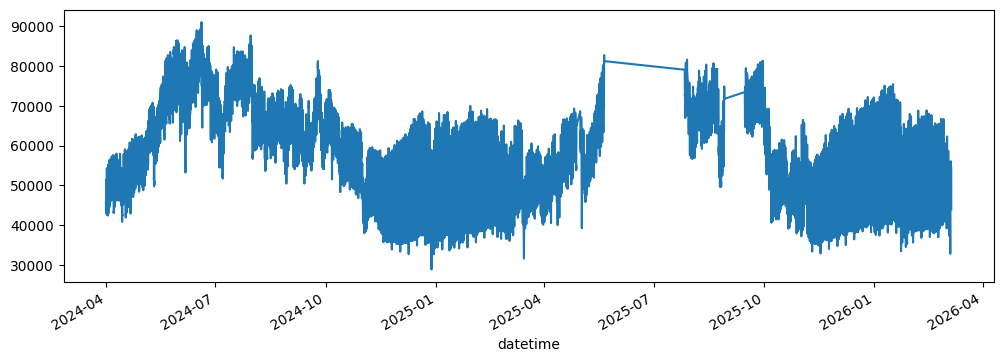

In [6]:
# plotting the trend
df['actual_demand_mw'].plot(figsize=(12,4))

## **Naive Baseline**

**What Nave Baseline model do?**
> It simply computes `Next Load = Current Load`

In [7]:
# train-test split
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [8]:
# naive prediction
naive_pred = test['actual_demand_mw'].shift(1)

In [9]:
# first prediction = last value from train
naive_pred.iloc[0] = train['actual_demand_mw'].iloc[-1]

In [10]:
# evaluation
mae = mean_absolute_error(test['actual_demand_mw'], naive_pred)
mse = mean_squared_error(test['actual_demand_mw'], naive_pred)
rmse = np.sqrt(mse)

print("Naive Baseline")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Naive Baseline
MAE: 758.60
RMSE: 951.16


##**Seasonal Naive Baseline**

**What Nave Seasonal Naive Baseline model do?**
> It simply computes `Next Load = Load from same time yesterday`

In [11]:
# data is of 15 min timestamp; 1D = 96 steps
season_length = 96

In [12]:
# shifiting values
seasonal_pred = test['actual_demand_mw'].shift(season_length)

In [13]:
# fill the missing predictions
seasonal_pred.iloc[:season_length] = train['actual_demand_mw'].iloc[-season_length:].values

In [14]:
# evaluation
mae = mean_absolute_error(test['actual_demand_mw'], seasonal_pred)
rmse = np.sqrt(mean_squared_error(test['actual_demand_mw'], seasonal_pred))

print("Seasonal Naive Baseline")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Seasonal Naive Baseline
MAE: 1759.93
RMSE: 2719.94


## **Insight from Baseline Models**

* **Naive Baseline**

  * **MAE:** 758.60
  * **RMSE:** 951.16

  > Shows lower error because short-term electricity demand changes smoothly between consecutive 15-minute intervals. Using the previous value as the next prediction captures this short-term continuity, making it a strong and realistic baseline for very short-horizon forecasting.

* **Seasonal Naive Baseline**

  * **MAE:** 1759.93
  * **RMSE:** 2719.94

  > Produces higher error because load patterns are not perfectly repeated from the same time on the previous day. Variations in demand due to temperature changes, weekday–weekend effects, and operational fluctuations reduce the effectiveness of simple daily seasonality assumptions.
